## Exercise 4: Conditional Graph


<img src="../assets/conditional_graph.png" width="500"/>
<br/>

<img src="../assets/exercise_4.png" width="500"/>

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [9]:
# Define the state schema of the agent
class AgentState(TypedDict):
    number1: float
    number2: float
    operation1: Literal['+', '-']
    number3: float
    number4: float
    operation2: Literal['+', '-']
    result1: float
    result2: float

In [10]:
def add_node(state: AgentState) -> AgentState:
    """This function adds the first two numbers and stores the result in the state."""
    state["result1"] = state["number1"] + state["number2"]
    return state

def subtract_node(state: AgentState) -> AgentState:
    """This function subtracts the second number from the first and stores the result in the state."""
    state["result1"] = state["number1"] - state["number2"]
    return state

def add_node_2(state: AgentState) -> AgentState:
    """This function adds the third and fourth numbers and stores the result in the state."""
    state["result2"] = state["number3"] + state["number4"]
    return state

def subtract_node_2(state: AgentState) -> AgentState:
    """This function subtracts the fourth number from the third and stores the result in the state."""
    state["result2"] = state["number3"] - state["number4"]
    return state

def decide_next_node_1(state: AgentState) -> str:
    """This function decides which operation to perform based on the operations specified in the state."""
    if state["operation1"] == "+":
        return "addition_operation"
    elif state["operation1"] == "-":
        return "subtraction_operation"
    
def decide_next_node_2(state: AgentState) -> str:
    """This function decides which operation to perform based on the operations specified in the state."""
    if state["operation2"] == "+":
        return "addition_operation_2"
    elif state["operation2"] == "-":
        return "subtraction_operation_2"

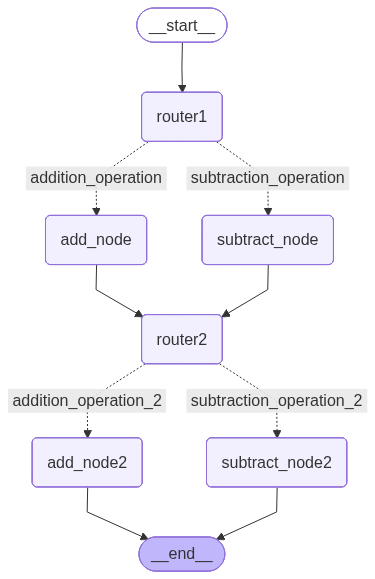

In [12]:
graph = StateGraph(AgentState)

# Define the graph structure

graph.add_node("add_node", add_node)
graph.add_node("subtract_node", subtract_node)

graph.add_node("add_node2", add_node_2)
graph.add_node("subtract_node2", subtract_node_2)

graph.add_node("router1", lambda state: state)  # This node will route to the next operation based on the state

graph.add_node("router2", lambda state: state)  # This node will route to the next operation based on the state

graph.add_edge(START, "router1")

graph.add_conditional_edges(
    "router1",
    decide_next_node_1,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node_2,
    {
        # edge: node
        "addition_operation_2": "add_node2",
        "subtraction_operation_2": "subtract_node2"
    }   
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

graph.compile()

In [14]:
app = graph.compile()

# Example usage
initial_state = AgentState(
    number1=10,
    operation1="+",
    number2=5,
    number3=20,
    operation2="-",
    number4=10,
    result1=0,
    result2=0
)

result = app.invoke(initial_state)

print(result)

{'number1': 10, 'number2': 5, 'operation1': '+', 'number3': 20, 'number4': 10, 'operation2': '-', 'result1': 15, 'result2': 10}
